In [35]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
df = pd.read_csv("../data/titanic.csv",usecols=['Age','Fare','Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [38]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [40]:
df["Age"] = df["Age"].fillna(df["Age"].mean())

In [41]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [42]:
X = df.iloc[:, 1:3]
y = df.iloc[:, -1]

In [43]:
from sklearn.model_selection import train_test_split

X_train,Xtest,y_train,y_test = train_test_split(X, y, test_size=0.3, random_state=1)

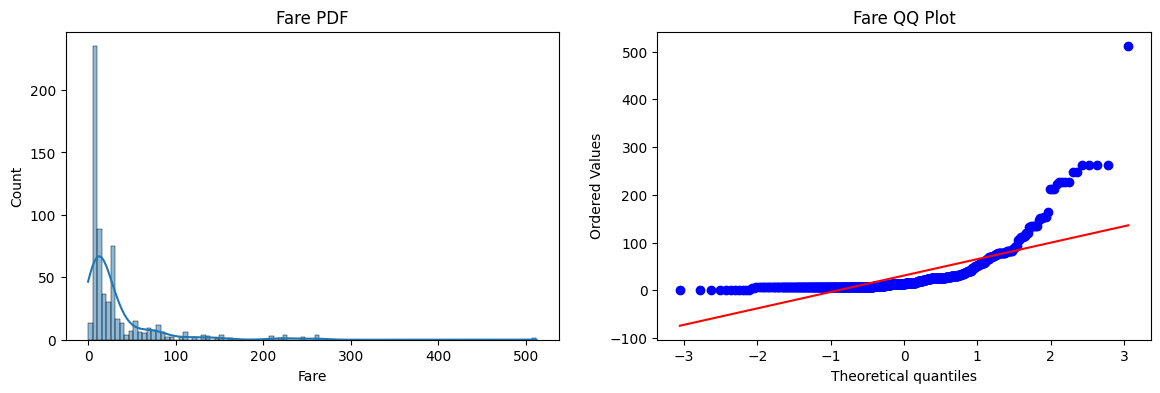

In [44]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.histplot(X_train["Fare"], kde=True)
plt.title("Fare PDF")

plt.subplot(122)
stats.probplot(X_train["Fare"], dist="norm", plot=plt)
plt.title('Fare QQ Plot')

plt.show()

In [52]:
from sklearn.preprocessing import FunctionTransformer

ft = FunctionTransformer(func=np.log1p)

X_trained_transformed = ft.fit_transform(X_train)

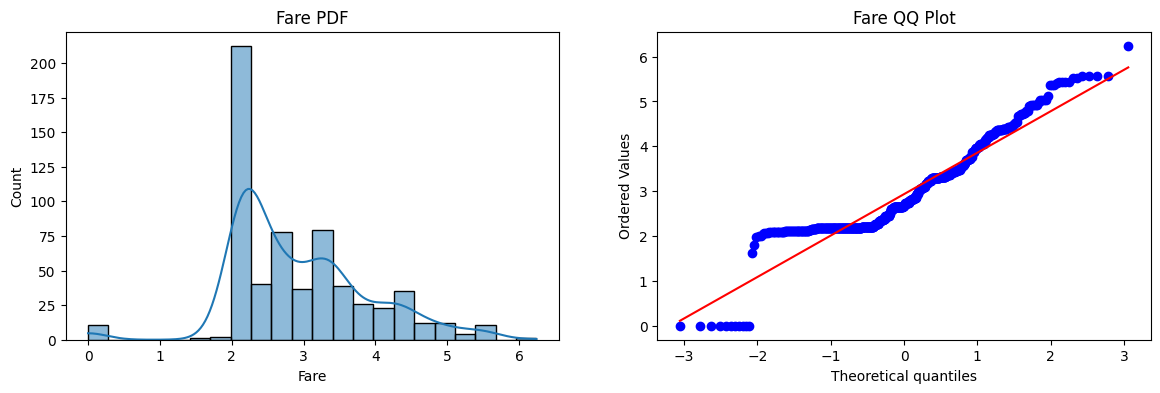

In [53]:
plt.figure(figsize=(14,4))

plt.subplot(121)
sns.histplot(X_trained_transformed["Fare"], kde=True)
plt.title("Fare PDF")

plt.subplot(122)
stats.probplot(X_trained_transformed["Fare"], dist="norm", plot=plt)
plt.title("Fare QQ Plot")

plt.show()